### Comparison of Pytorch vs. Keras/Tensorflow

In [ ]:
# =========================
# 0. GPU validation for Pytorch
# =========================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"Is CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    
    x = torch.tensor([1.0, 2.0]).to("cuda")
    print(f"Test tensor on GPU: {x}")
else:
    print("Check failed: PyTorch cannot access your GPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    

[I 2026-05-12 08:40:28,983] A new study created in memory with name: no-name-85b96618-eae8-4d92-a689-314edaea411c


Device: cuda
X_train_full: (800, 58)
X_test      : (200, 58)
y_train_full: (800,)
y_test      : (200,)
Classes     : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Input dim   : 58
Num classes : 10

OPTUNA TUNING


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-05-12 08:40:30,444] Trial 0 finished with value: 0.7166666666666667 and parameters: {'n_layers': 3, 'hidden_dim_0': 128, 'dropout_0': 0.07799726016810132, 'hidden_dim_1': 256, 'dropout_1': 0.010292247147901223, 'hidden_dim_2': 128, 'dropout_2': 0.09170225492671691, 'optimizer': 'Adamax', 'lr': 0.0003124565071260876, 'weight_decay': 2.8016351587162606e-05, 'batch_size': 256}. Best is trial 0 with value: 0.7166666666666667.
[I 2026-05-12 08:40:31,124] Trial 1 finished with value: 0.7666666666666667 and parameters: {'n_layers': 3, 'hidden_dim_0': 128, 'dropout_0': 0.023225206359998862, 'hidden_dim_1': 1024, 'dropout_1': 0.4828160165372797, 'hidden_dim_2': 128, 'dropout_2': 0.22007624686980065, 'optimizer': 'Adamax', 'lr': 0.0035067764992972213, 'weight_decay': 1.0842262717330158e-06, 'batch_size': 64}. Best is trial 1 with value: 0.7666666666666667.
[I 2026-05-12 08:40:31,840] Trial 2 finished with value: 0.75 and parameters: {'n_layers': 3, 'hidden_dim_0': 256, 'dropout_0': 0.447

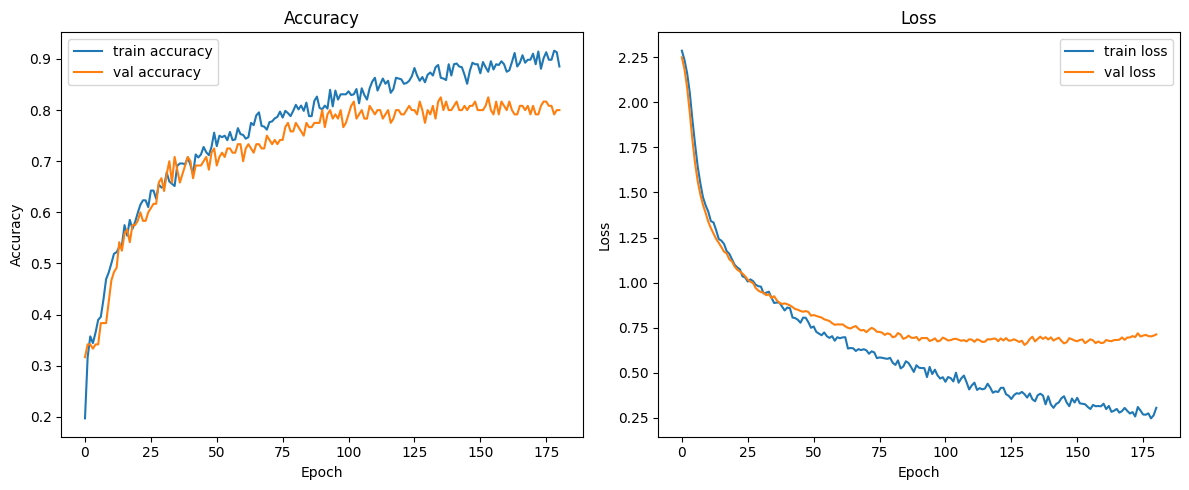


Saved files:
- ./Output\music_best_params_optuna.json
- ./Output\music_results_pytorch_optuna.csv
- ./Output\music_genre_pytorch_optuna.pt
- ./Output\music_genre_artifacts.pkl
- ./Output\music_training_curves_pytorch_optuna.png

Preview:
     length  chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
171  661794          0.208080         0.082618  0.051681  0.001591   
92   661794          0.390914         0.100480  0.063084  0.001534   
670  661504          0.414736         0.089662  0.048849  0.000753   
535  661794          0.264600         0.089984  0.091492  0.001231   
21   661794          0.321100         0.103292  0.101132  0.003228   
243  661794          0.403080         0.082270  0.095036  0.001467   
955  661794          0.431647         0.073647  0.147185  0.002299   
254  661794          0.312862         0.089017  0.104327  0.000899   
485  661794          0.476623         0.088298  0.106245  0.001945   
557  661794          0.234168         0.092644  0.078136  0.0

In [4]:
# =========================
# 1. IMPORTS
# =========================
import os, json, pickle, random, warnings, optuna
from copy import copy, deepcopy
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 100)
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

#=========================
# 2. CONFIG
# =========================
SEED = 42

DATA_PATH = "./Input/features_30_sec.csv"
OUTPUT_DIR = "./Output"

# Optuna
N_TRIALS = 40
TUNING_MAX_EPOCHS = 150
TUNING_PATIENCE = 20

# Final training
FINAL_MAX_EPOCHS = 500
FINAL_PATIENCE = 50

# Data split
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.15

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Device:", DEVICE)

# =========================
# 3. LOAD DATA
# =========================
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["filename"]).copy()
df = df.dropna().reset_index(drop=True)

# =========================
# 4. LABEL ENCODING
# =========================
class_names = sorted(df["label"].unique())
label_map = {name: idx for idx, name in enumerate(class_names)}
idx_to_label = {idx: name for name, idx in label_map.items()}

df["label"] = df["label"].map(label_map).astype("int64")

# =========================
# 5. OUTER SPLIT (TRAIN / TEST)
# =========================
X = df.drop(columns=["label"])
y = df["label"]

X_train_full_df, X_test_df, y_train_full, y_test = train_test_split(X,y,test_size=TEST_SIZE,random_state=SEED,stratify=y)

print("X_train_full:", X_train_full_df.shape)
print("X_test      :", X_test_df.shape)
print("y_train_full:", y_train_full.shape)
print("y_test      :", y_test.shape)
print("Classes     :", class_names)

input_dim = X_train_full_df.shape[1]
num_classes = len(class_names)

print("Input dim   :", input_dim)
print("Num classes :", num_classes)

# =========================
# 6. HELPERS
# =========================
def make_loaders(X_train_np,y_train_np,X_val_np,y_val_np,batch_size: int):
    X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)

    X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_np, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=0,pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False,num_workers=0,pin_memory=torch.cuda.is_available())

    return train_loader, val_loader


class MusicGenreNet(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims, dropouts):
        super().__init__()

        layers_list = []
        prev_dim = input_dim

        for i, hidden_dim in enumerate(hidden_dims):
            layers_list.append(nn.Linear(prev_dim, hidden_dim))
            layers_list.append(nn.ReLU())

            if i < len(dropouts) and dropouts[i] > 0:
                layers_list.append(nn.Dropout(dropouts[i]))

            prev_dim = hidden_dim

        layers_list.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers_list)

    def forward(self, x):
        return self.network(x)


def build_optimizer(model, optimizer_name, lr, weight_decay):
    if optimizer_name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "Adamax":
        return torch.optim.Adamax(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def predict_proba(model, X_np, batch_size=256, device=DEVICE):
    model.eval()

    X_tensor = torch.tensor(X_np, dtype=torch.float32)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset,batch_size=batch_size,shuffle=False,num_workers=0,pin_memory=torch.cuda.is_available())

    outputs = []

    with torch.no_grad():
        for (X_batch,) in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            outputs.append(probs.cpu().numpy())

    return np.vstack(outputs)


class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.best_state = None
        self.best_epoch = 0

    def step(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_epoch = epoch
            self.best_state = deepcopy(model.state_dict())
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience


# =========================
# 7. OPTUNA OBJECTIVE
# =========================
def objective(trial):
    seed_everything(SEED)

    # Tuning split inside training set only
    X_tr_df, X_val_df, y_tr, y_val = train_test_split(
                                                        X_train_full_df,
                                                        y_train_full,
                                                        test_size=VAL_SIZE_WITHIN_TRAIN,
                                                        random_state=SEED,
                                                        stratify=y_train_full
                                                    )

    # Hyperparameters
    n_layers = trial.suggest_int("n_layers", 2, 4)

    hidden_dims = []
    dropouts = []

    for i in range(n_layers):
        hidden_dims.append(trial.suggest_categorical(f"hidden_dim_{i}", [128, 256, 512, 1024]))
        dropouts.append(trial.suggest_float(f"dropout_{i}", 0.0, 0.5))

    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "Adamax", "AdamW"])
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

    # Scaling inside trial
    scaler_trial = StandardScaler()
    X_tr = scaler_trial.fit_transform(X_tr_df).astype(np.float32)
    X_val = scaler_trial.transform(X_val_df).astype(np.float32)

    y_tr = np.asarray(y_tr, dtype=np.int64)
    y_val = np.asarray(y_val, dtype=np.int64)

    train_loader, val_loader = make_loaders(X_tr, y_tr, X_val, y_val, batch_size=batch_size)

    model = MusicGenreNet(input_dim=input_dim,num_classes=num_classes,hidden_dims=hidden_dims,dropouts=dropouts).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, optimizer_name, lr, weight_decay)

    early_stopping = EarlyStopping(patience=TUNING_PATIENCE)

    for epoch in range(1, TUNING_MAX_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

        trial.report(val_acc, step=epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

        should_stop = early_stopping.step(val_loss, model, epoch)
        if should_stop:
            break

    if early_stopping.best_state is not None:
        model.load_state_dict(early_stopping.best_state)

    final_val_loss, final_val_acc = evaluate(model, val_loader, criterion, DEVICE)
    return final_val_acc


# =========================
# 8. RUN OPTUNA
# =========================
print("\n" + "=" * 60)
print("OPTUNA TUNING")
print("=" * 60)

study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED),pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10))

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_trial.params

print("\nBest trial value (val_accuracy):", study.best_trial.value)
print("Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

with open(os.path.join(OUTPUT_DIR, "music_best_params_optuna.json"), "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, ensure_ascii=False)

# =========================
# 9. FINAL TRAIN / VALIDATION SPLIT
# =========================
X_train_df, X_val_df, y_train, y_val = train_test_split(X_train_full_df,y_train_full,test_size=VAL_SIZE_WITHIN_TRAIN,random_state=SEED,stratify=y_train_full)

# Fit scaler only on final train split
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val = scaler.transform(X_val_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)

y_train = np.asarray(y_train, dtype=np.int64)
y_val = np.asarray(y_val, dtype=np.int64)
y_test_np = np.asarray(y_test, dtype=np.int64)

best_hidden_dims = [best_params[f"hidden_dim_{i}"] for i in range(best_params["n_layers"])]
best_dropouts = [best_params[f"dropout_{i}"] for i in range(best_params["n_layers"])]
best_batch_size = best_params["batch_size"]

train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, batch_size=best_batch_size)

# Test loader for final evaluation
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset,batch_size=best_batch_size,shuffle=False,num_workers=0,pin_memory=torch.cuda.is_available())

# =========================
# 10. FINAL MODEL
# =========================
model = MusicGenreNet(input_dim=input_dim,num_classes=num_classes,hidden_dims=best_hidden_dims,dropouts=best_dropouts).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = build_optimizer(model=model,optimizer_name=best_params["optimizer"],lr=best_params["lr"],weight_decay=best_params["weight_decay"])

print("\n" + "=" * 60)
print("FINAL TRAINING")
print("=" * 60)
print(model)

# =========================
# 11. FINAL TRAINING LOOP
# =========================
history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": []
            }

early_stopping = EarlyStopping(patience=FINAL_PATIENCE)

for epoch in range(1, FINAL_MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch:03d}/{FINAL_MAX_EPOCHS}] | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    should_stop = early_stopping.step(val_loss, model, epoch)
    if should_stop:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)
    print(f"Best model restored from epoch {early_stopping.best_epoch}.")

# =========================
# 12. FINAL TEST EVALUATION
# =========================
test_loss, test_accuracy = evaluate(model, test_loader, criterion, DEVICE)
print(f"\nTest loss     = {test_loss:.4f}")
print(f"Test accuracy = {test_accuracy:.4f}")

# =========================
# 13. PREDICTIONS + REPORT
# =========================
pred_proba = predict_proba(model, X_test, batch_size=best_batch_size, device=DEVICE)
pred_idx = np.argmax(pred_proba, axis=1)

print("\nClassification report:\n")
print(classification_report(y_test_np,pred_idx,target_names=class_names,digits=4))

# =========================
# 14. PLOTS
# =========================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_acc"], label="train accuracy")
plt.plot(history["val_acc"], label="val accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "music_training_curves_pytorch_optuna.png"), dpi=150)
plt.show()

# =========================
# 15. EXPORT RESULTS
# =========================
results = X_test_df.copy()
results["label_true"] = [idx_to_label[i] for i in y_test_np]
results["label_predicted"] = [idx_to_label[i] for i in pred_idx]
results["prediction_confidence"] = pred_proba.max(axis=1)

results.to_csv(os.path.join(OUTPUT_DIR, "music_results_pytorch_optuna.csv"),index=True,header=True)

# Save model weights
torch.save(model.state_dict(),os.path.join(OUTPUT_DIR, "music_genre_pytorch_optuna.pt"))

# Save scaler + metadata for inference
artifacts = {
                "scaler": scaler,
                "class_names": class_names,
                "label_map": label_map,
                "idx_to_label": idx_to_label,
                "input_dim": input_dim,
                "num_classes": num_classes,
                "best_params": best_params
            }

with open(os.path.join(OUTPUT_DIR, "music_genre_artifacts.pkl"), "wb") as f:
    pickle.dump(artifacts, f)

print("\nSaved files:")
print("-", os.path.join(OUTPUT_DIR, "music_best_params_optuna.json"))
print("-", os.path.join(OUTPUT_DIR, "music_results_pytorch_optuna.csv"))
print("-", os.path.join(OUTPUT_DIR, "music_genre_pytorch_optuna.pt"))
print("-", os.path.join(OUTPUT_DIR, "music_genre_artifacts.pkl"))
print("-", os.path.join(OUTPUT_DIR, "music_training_curves_pytorch_optuna.png"))

print("\nPreview:")
print(results.head(20))